# Hybrid PEC tip optimization

This notebook studies persistent sharp PEC tips with a hybrid boundary and geometry-aware mesh optimization. The exact geometry stays continuous; hybrid fallback coefficients are diagnosed locally. The source is always a +x plane wave, so incidence-study orientations are made by explicitly rotating the coordinate arrays.

All cells are output-free in the saved artifact. CPU geometry preparation and plots run by default. GPU reference qualification and optimization are opt-in and make no global-optimality claim.

Recorded GPU results and limitations are in the [experiment report](../docs/hybrid_tip_optimization.md): the tip-and-block searches improved both budgets; the star reference remained unqualified and its search was skipped.


In [1]:
from pathlib import Path
import sys
import json
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/fdtdmesh').is_dir())
sys.path.insert(0, str(ROOT / 'src'))
import fdtdmesh as fd
from fdtdmesh.boundary import BoundaryPolicy
from fdtdmesh.domain import DomainPolicy
from fdtdmesh.meshing import MeshOptions
from fdtdmesh.optimization import SearchSettings, ReferenceSettings, qualify_reference, optimize_mesh

CASES = ['notebook_tip', 'star']
ORIENTATIONS = [0, 30]
BUDGETS = [(120, 120), (160, 160)]
RUN_GPU = False
MAX_EVALUATIONS = 40  # editable up to 200
FMIN, FMAX = 0.95e9, 1.05e9
OUT = ROOT / 'artifacts' / 'notebooks' / 'hybrid_tip_optimization'
OUT.mkdir(parents=True, exist_ok=True)


## User controls and interpretation

| control | meaning |
|---|---|
`CASES` | `notebook_tip` reproduces the notebook 03 polygon plus block; `star` is a seven-point alternating-radius star |
`ORIENTATIONS` | coordinate-array rotations in degrees; the source remains +x |
`BUDGETS` | exact total mesh cell budgets used for CPU preparation and, when enabled, optimization |
`RUN_GPU` | enables one reference qualification per shape/orientation and all requested optimizations |
`MAX_EVALUATIONS` | bounded feasible-local search budget, editable from 40 to 200 |

A qualified reference is a gate: optimization is never run with an incomplete or unqualified reference. Shrinking physical fallback patches (area or diameter) is a spatial geometry diagnostic; zero fallback cells alone is not temporal convergence. Reference qualification checks temporal and spatial sensitivity separately.

In [2]:
def rotate_points(points, angle_deg, origin=(0.0, 0.0)):
    """Rotate coordinate arrays explicitly; the incident source direction stays +x."""
    pts = np.asarray(points, dtype=float)
    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    r = np.array([[c, -s], [s, c]])
    o = np.asarray(origin, dtype=float)
    return (pts - o) @ r.T + o

def notebook_tip_recipe(lam):
    # Exact sharp polygon and nearby rectangular block from notebook 03.
    tip = np.array([(2.25, 2.2), (3.0, 3.0), (2.25, 3.8), (2.45, 3.0)]) * lam
    block = np.array([(3.08, 2.72), (3.42, 2.72), (3.42, 3.28), (3.08, 3.28)]) * lam
    return [tip, block]

def star_recipe(lam):
    # Seven-point star outline: 14 vertices with alternating .75/.30 radii.
    angles = np.arange(14) * 2 * np.pi / 14
    radii = np.where(np.arange(14) % 2 == 0, 0.75, 0.30) * lam
    return [np.c_[radii * np.cos(angles), radii * np.sin(angles)]]

def recipe(name, lam):
    if name == 'notebook_tip':
        return notebook_tip_recipe(lam)
    if name == 'star':
        return star_recipe(lam)
    raise KeyError(name)

def make_sim(name, orientation):
    lam = fd.C0 / ((FMIN + FMAX) / 2)
    arrays = recipe(name, lam)
    center = np.mean(np.vstack(arrays), axis=0)
    arrays = [rotate_points(a, orientation, origin=center) - center for a in arrays]
    sim = fd.Simulation(
        fmin=FMIN, fmax=FMAX,
        solver=fd.SolverSettings(dft_bins=3, stop=fd.DFTConvergence(max_steps=500_000)),
        boundary=BoundaryPolicy(mode='hybrid'),
        domain=DomainPolicy(margin_mesh='graded'),
    )
    sim.add_polygon(arrays[0], name=name + '-tip')
    if name == 'notebook_tip':
        sim.add_polygon(arrays[1], name='notebook03-block')
    return sim


## CPU preparation and boundary diagnostics

`hybrid_repair_passes=3` bounds geometry repairs. The TFSF scatterer margins may grade, while the exterior TFSF allocation remains fixed. Each case and angle gets its own archive directory.

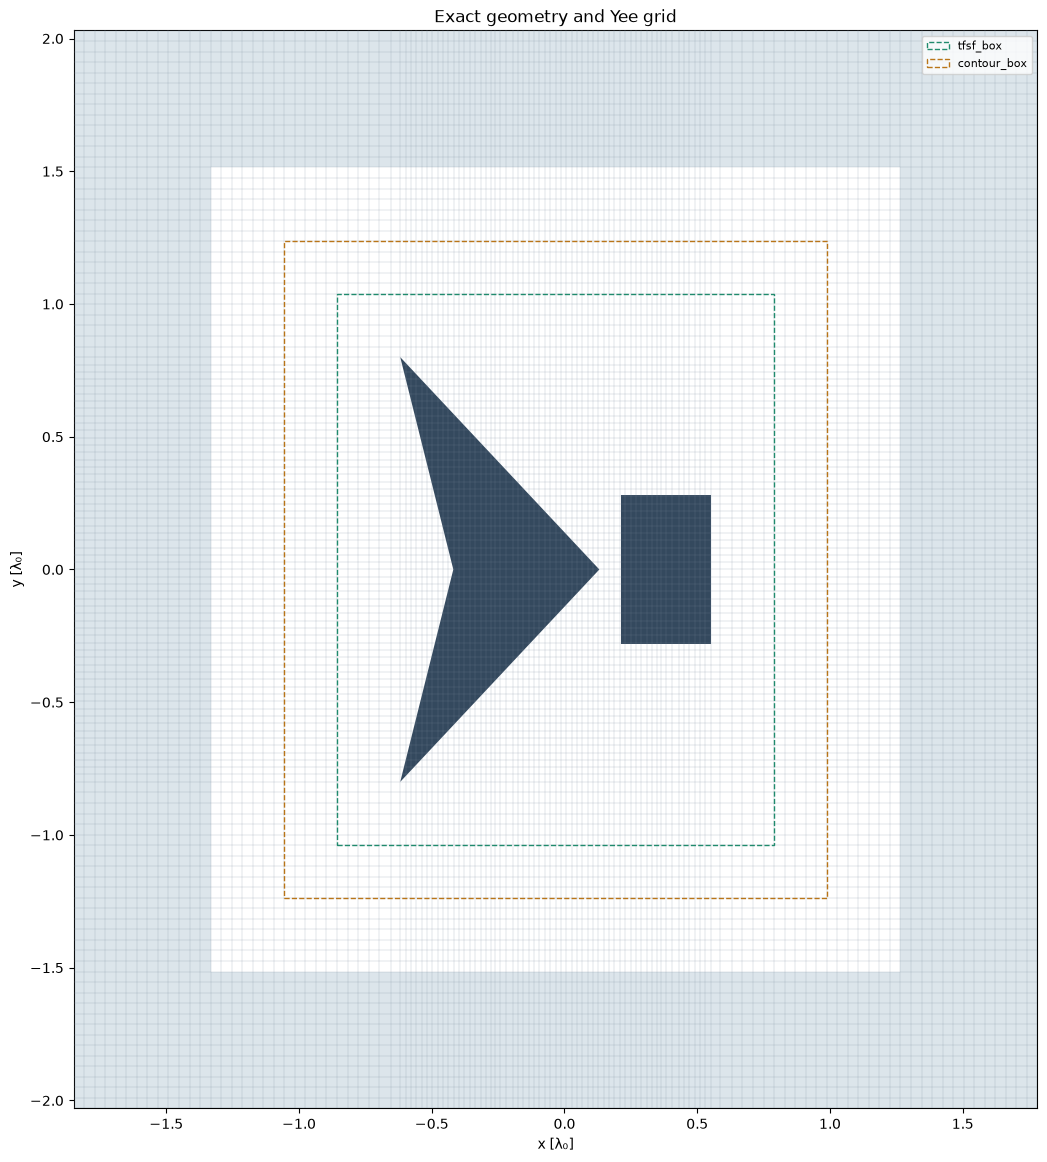

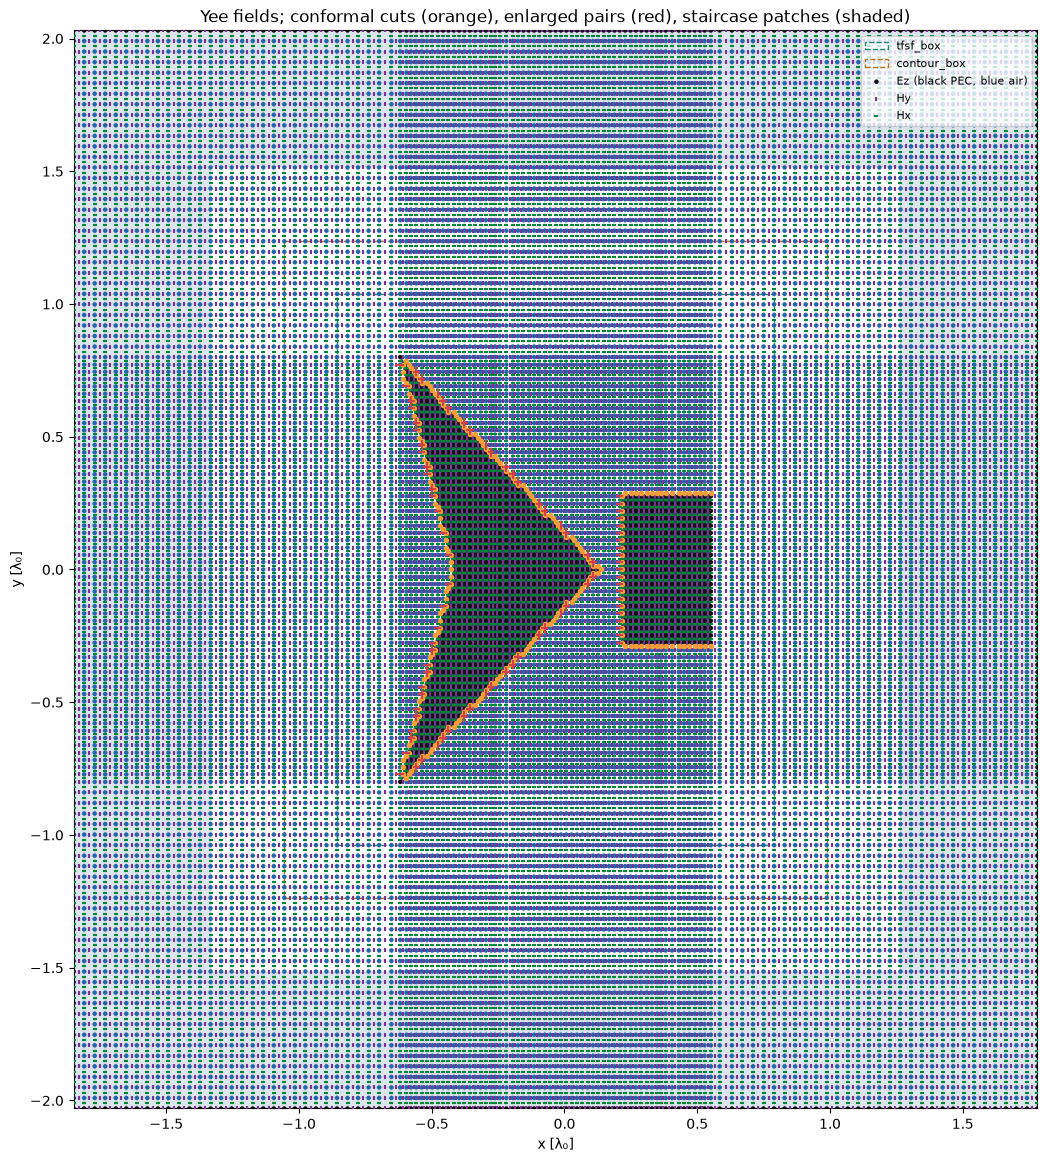

notebook_tip 0 (120, 120) {'fallback_cells': 0, 'fallback_area_m2': 0.0, 'fallback_max_diameter_m': 0.0, 'patches': [], 'termination_reason': 'fully_conformal', 'passes': [{'cells': [120, 120], 'anchors': [2, 1], 'assignment': 'local', 'status': 'valid', 'violations': 0, 'topology_violations': 0, 'donor_violations': 0, 'fallback_cells': 0, 'fallback_area_m2': 0.0, 'fallback_max_diameter_m': 0.0}]}


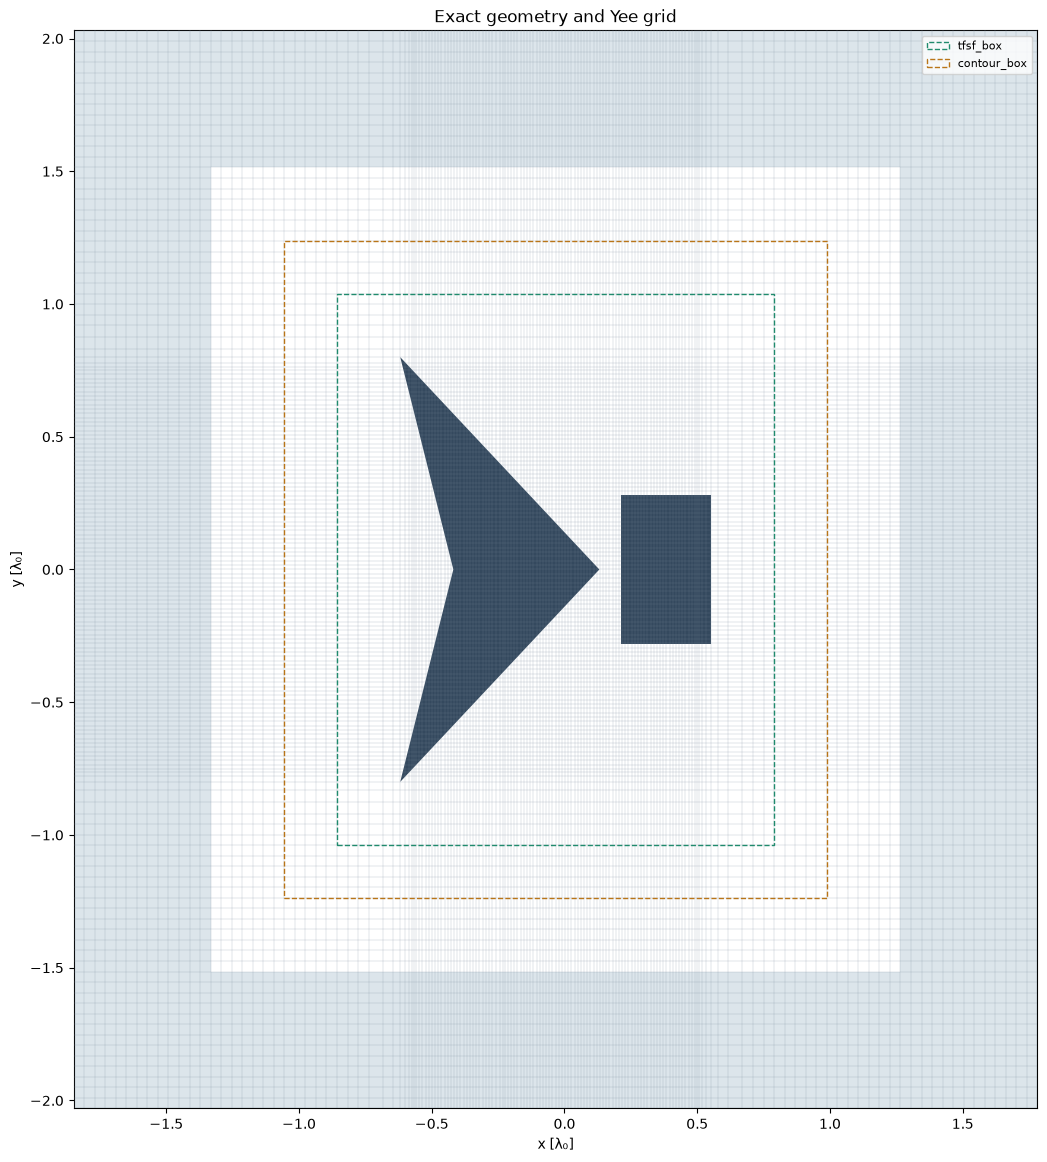

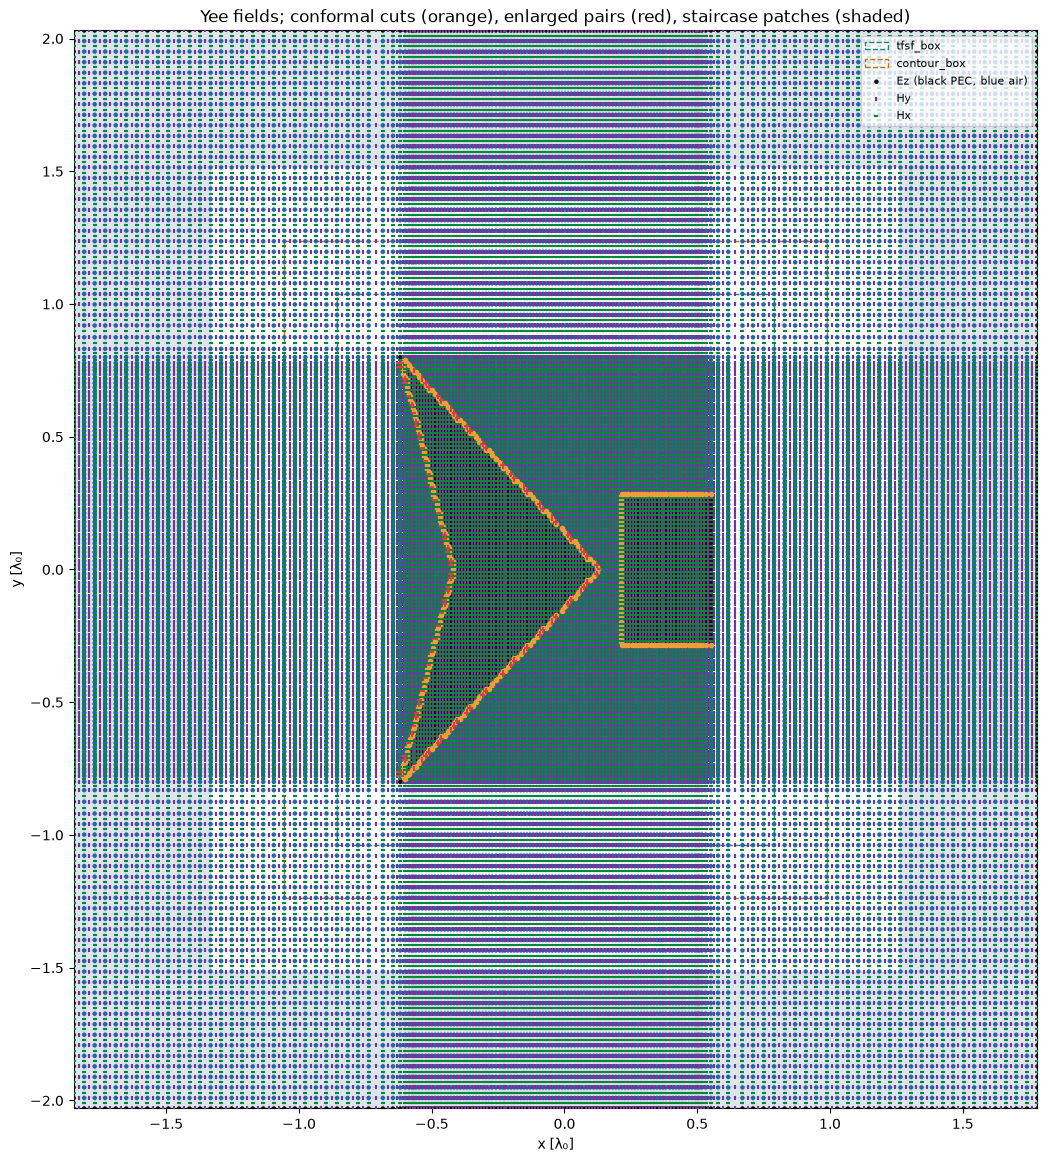

notebook_tip 0 (160, 160) {'fallback_cells': 0, 'fallback_area_m2': 0.0, 'fallback_max_diameter_m': 0.0, 'patches': [], 'termination_reason': 'fully_conformal', 'passes': [{'cells': [160, 160], 'anchors': [2, 1], 'assignment': 'local', 'status': 'valid', 'violations': 0, 'topology_violations': 0, 'donor_violations': 0, 'fallback_cells': 0, 'fallback_area_m2': 0.0, 'fallback_max_diameter_m': 0.0}]}


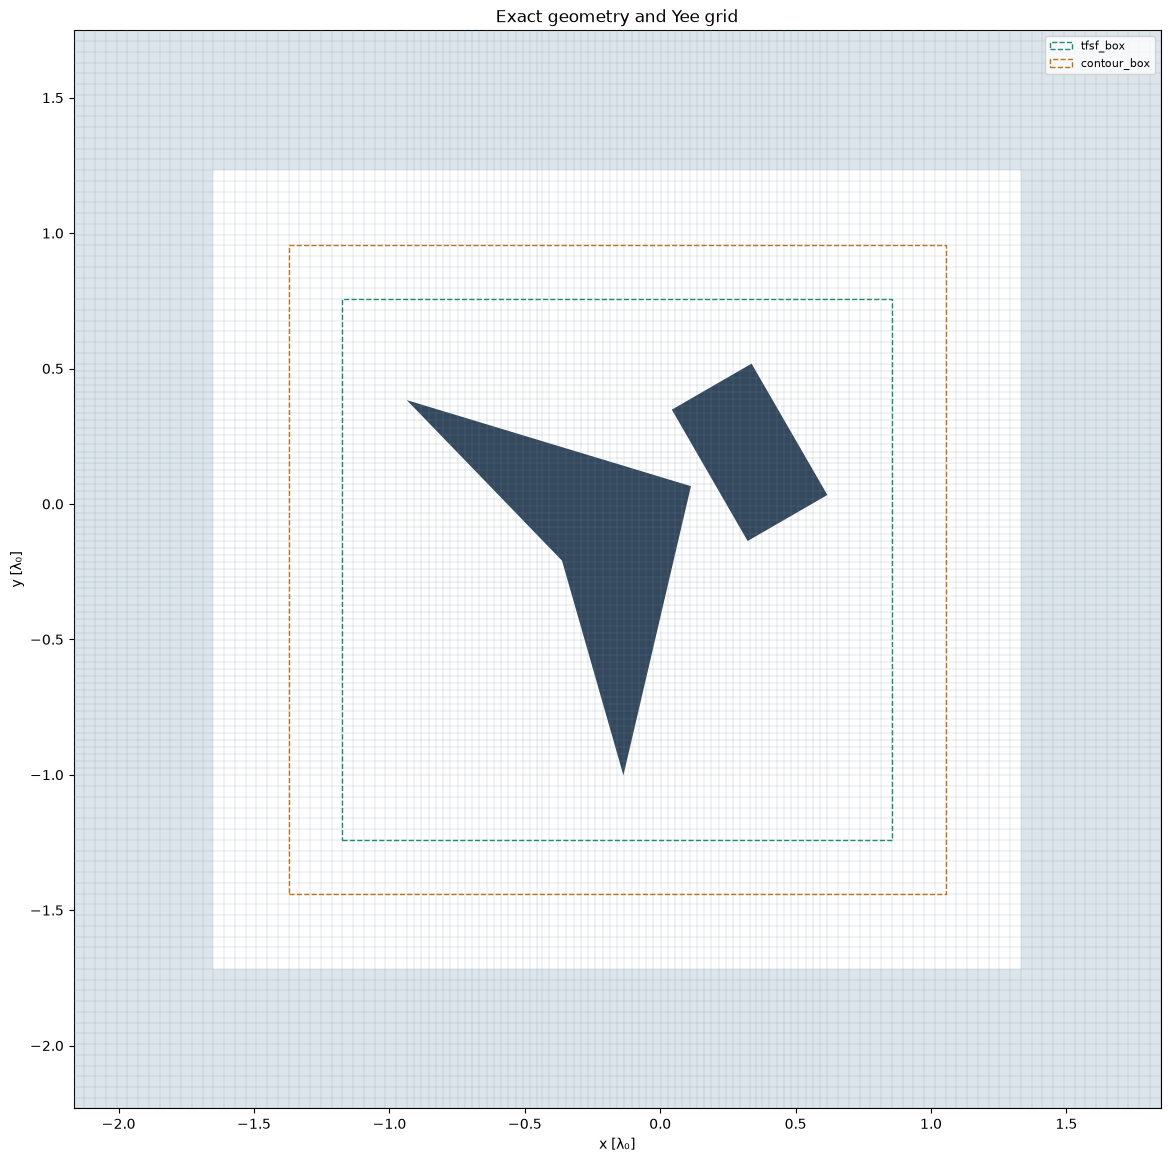

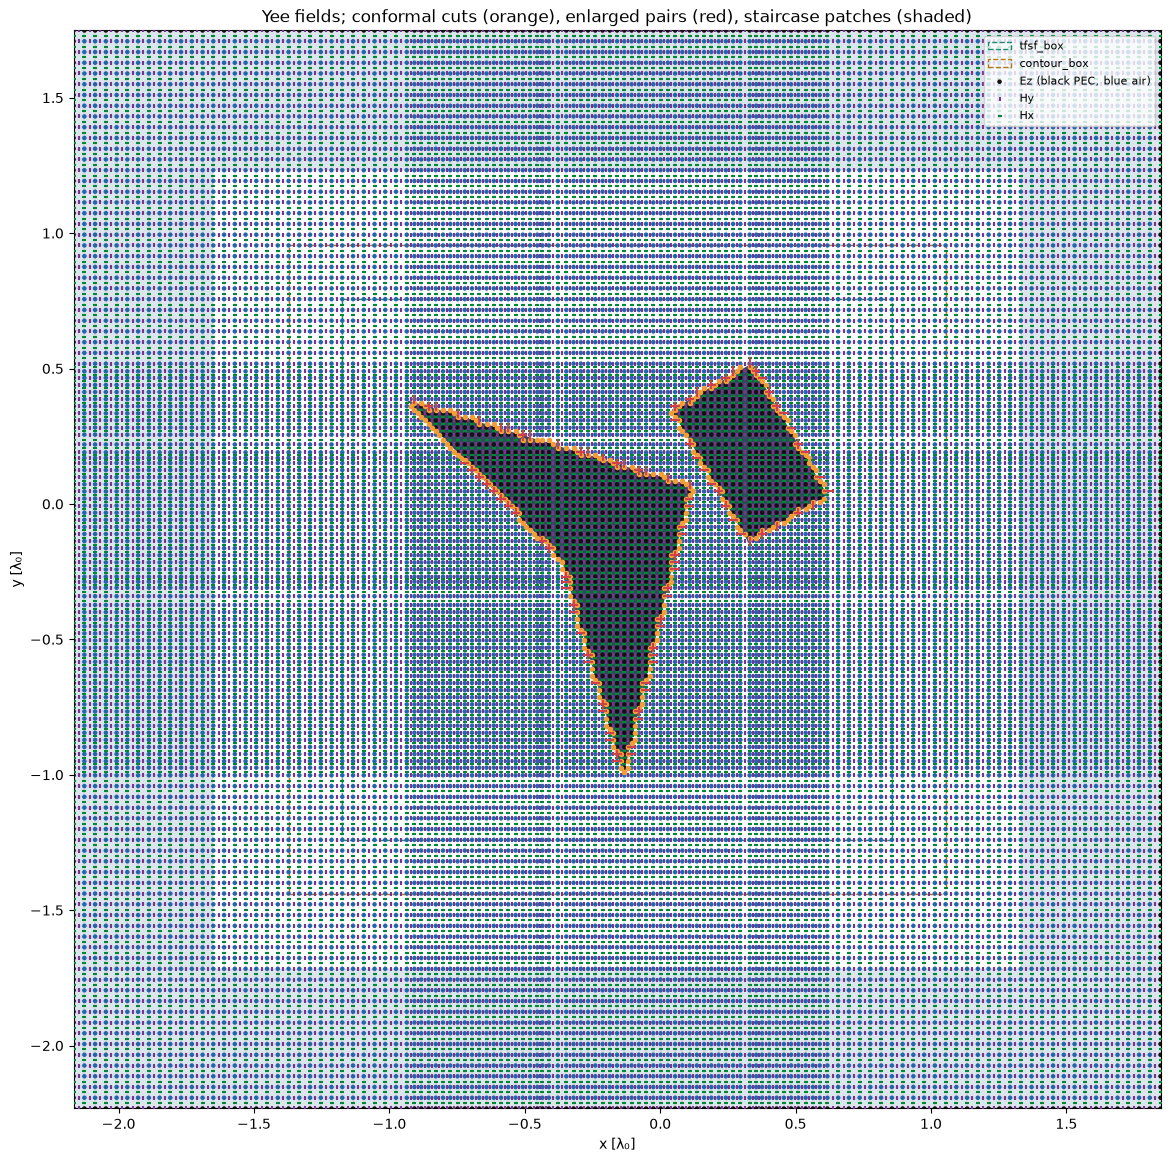

notebook_tip 30 (120, 120) {'fallback_cells': 0, 'fallback_area_m2': 0.0, 'fallback_max_diameter_m': 0.0, 'patches': [], 'termination_reason': 'fully_conformal', 'passes': [{'cells': [120, 120], 'anchors': [2, 2], 'assignment': 'local', 'status': 'valid', 'violations': 0, 'topology_violations': 0, 'donor_violations': 0, 'fallback_cells': 0, 'fallback_area_m2': 0.0, 'fallback_max_diameter_m': 0.0}]}


C:\Users\Traveler\PycharmProjects\FDTD_ML\src\fdtdmesh\solver\coefficients.py:36: StaircaseFallbackWarning: Local staircase fallback in 6 cells (0.010% domain area); thin PEC/gaps may be lost. Inspect discretization diagnostics.
  pec, hx, hy, bound = build_conformal(scene, mesh, boundary=boundary, report=report, warn=True)


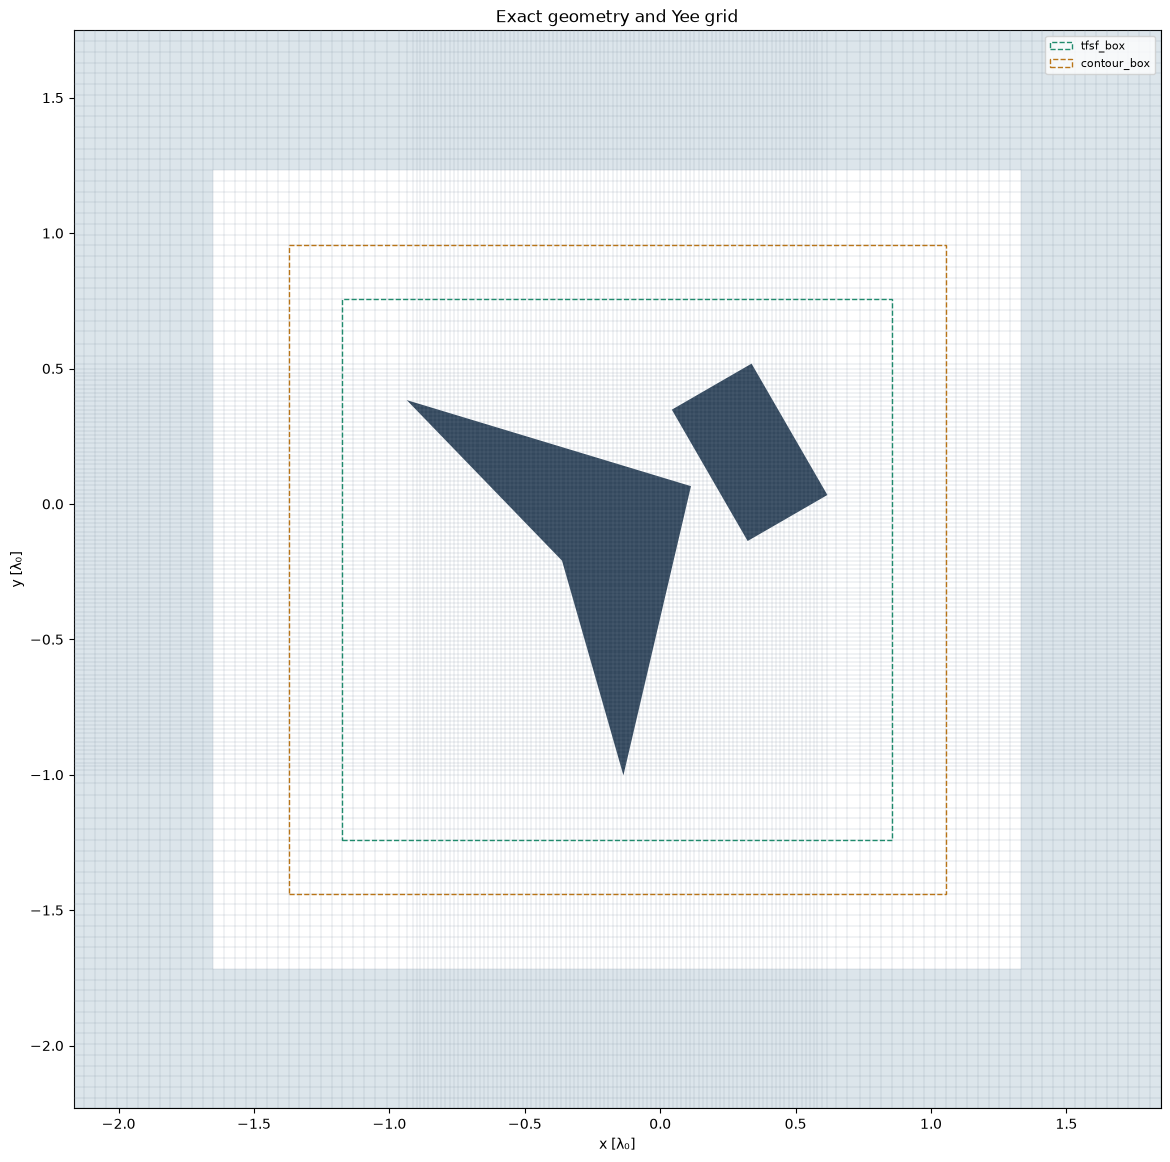

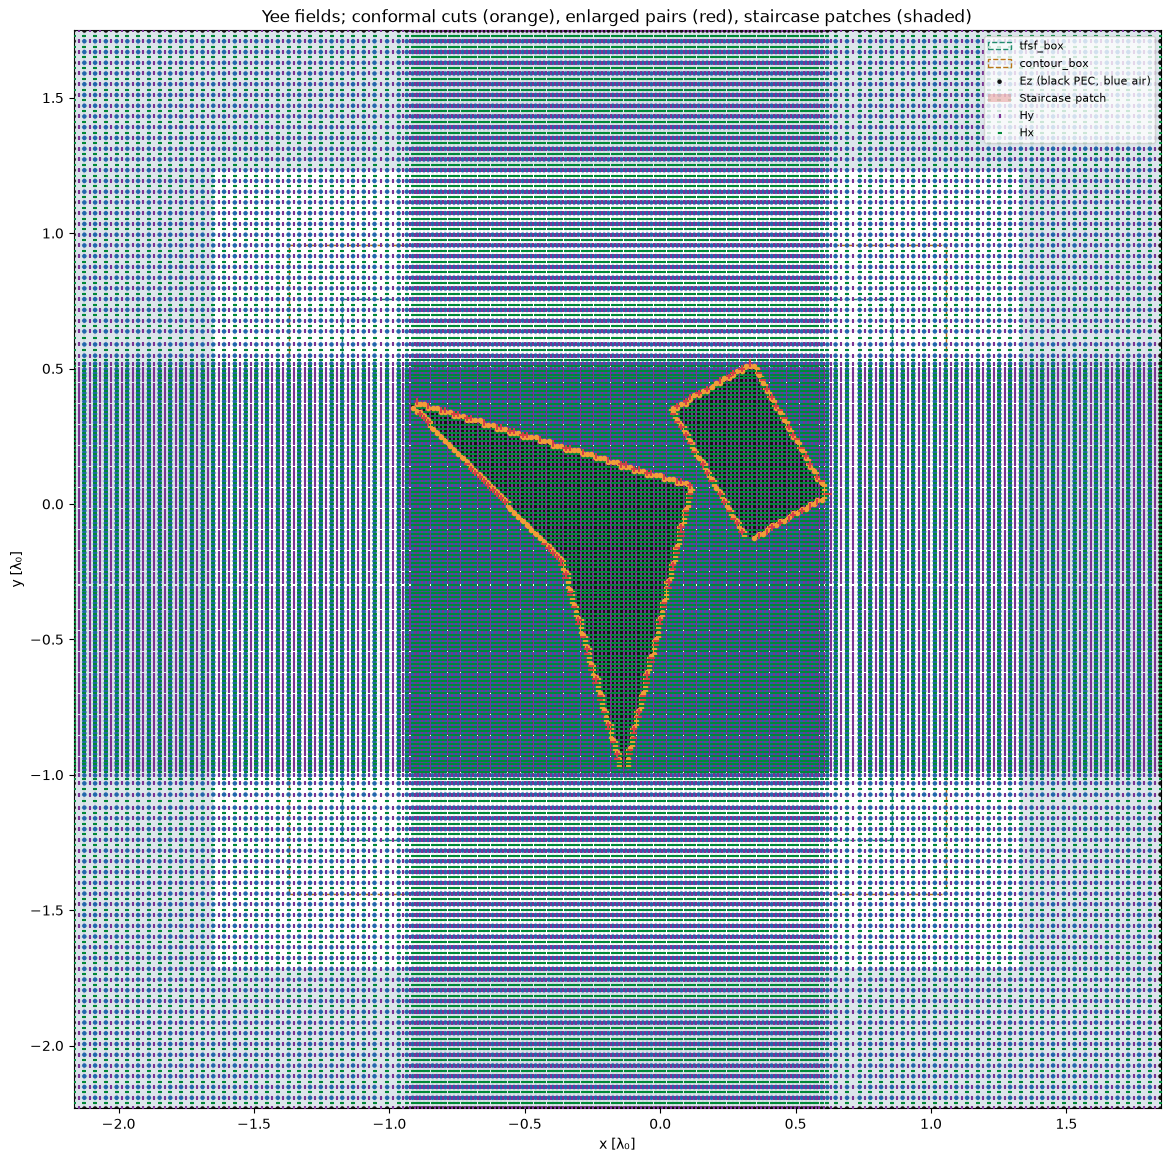

notebook_tip 30 (160, 160) {'fallback_cells': 6, 'fallback_area_m2': 0.00015052510494972373, 'fallback_max_diameter_m': 0.011846494163079757, 'patches': [{'cells': 2, 'area_m2': 6.0156911864384224e-05, 'bounds': [0.3687923094444444, 0.3752597060024229, 0.7780611857695736, 0.7873627511405994], 'diameter_m': 0.011329004218801324}, {'cells': 2, 'area_m2': 5.1563067312328286e-05, 'bounds': [0.6063701421865086, 0.6111216988413499, 0.3687923094444444, 0.3796441357106411], 'diameter_m': 0.011846494163079757}, {'cells': 2, 'area_m2': 3.880512577301119e-05, 'bounds': [0.7441652851769059, 0.7483371771354239, 0.6245853571476502, 0.6338869225186758], 'diameter_m': 0.010194302372649674}], 'termination_reason': 'retained_best_hybrid', 'passes': [{'cells': [160, 160], 'anchors': [2, 2], 'assignment': 'local', 'status': 'valid', 'violations': 3, 'topology_violations': 3, 'donor_violations': 0, 'fallback_cells': 6, 'fallback_area_m2': 0.00015052510494972373, 'fallback_max_diameter_m': 0.011846494163079

C:\Users\Traveler\PycharmProjects\FDTD_ML\src\fdtdmesh\solver\coefficients.py:36: StaircaseFallbackWarning: Local staircase fallback in 22 cells (0.089% domain area); thin PEC/gaps may be lost. Inspect discretization diagnostics.
  pec, hx, hy, bound = build_conformal(scene, mesh, boundary=boundary, report=report, warn=True)


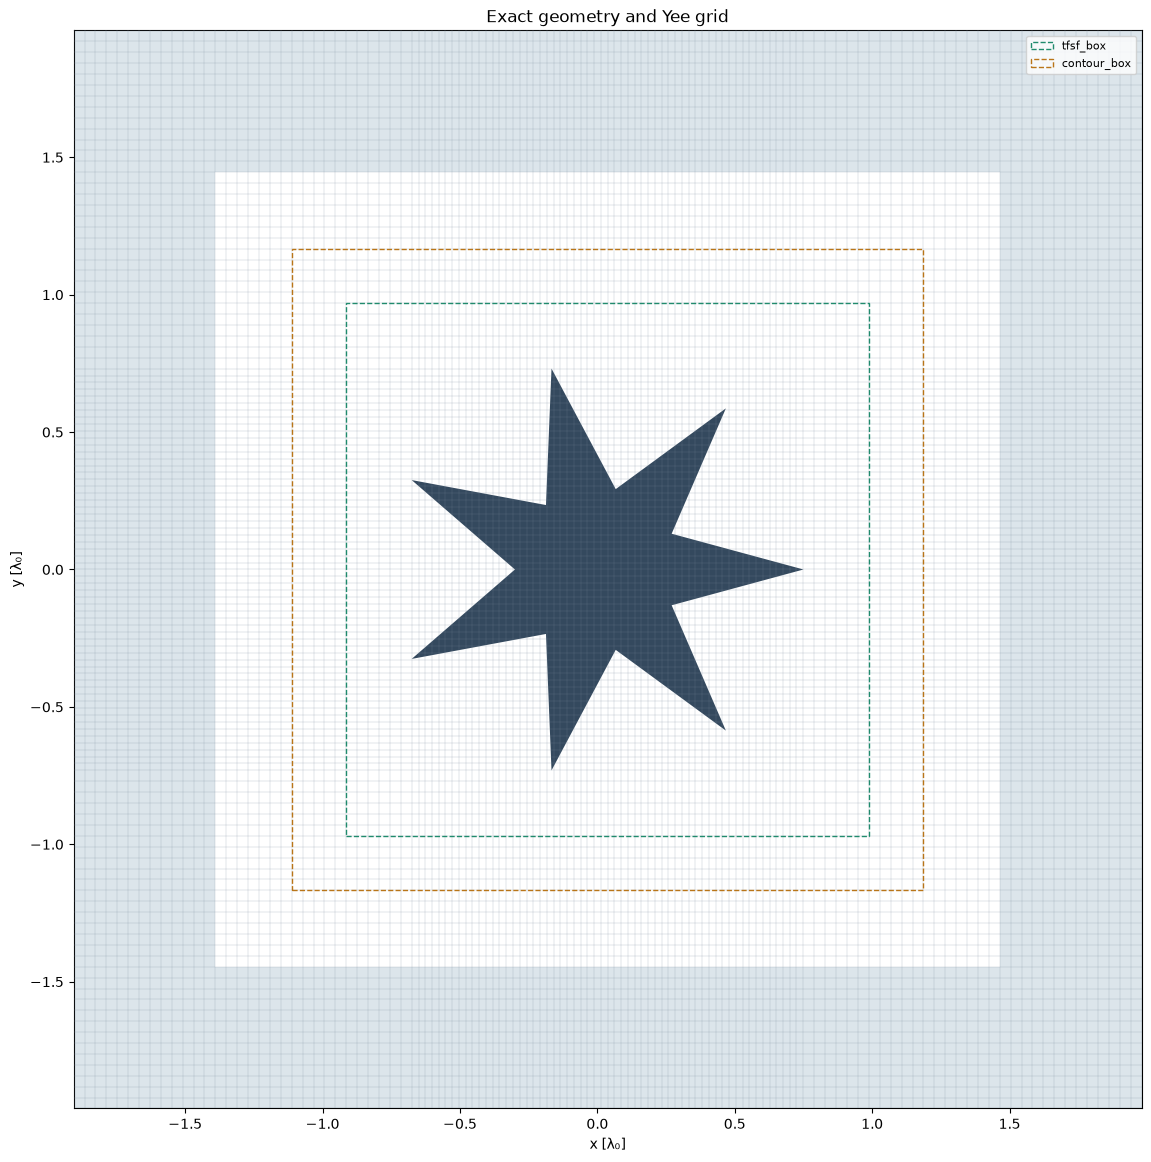

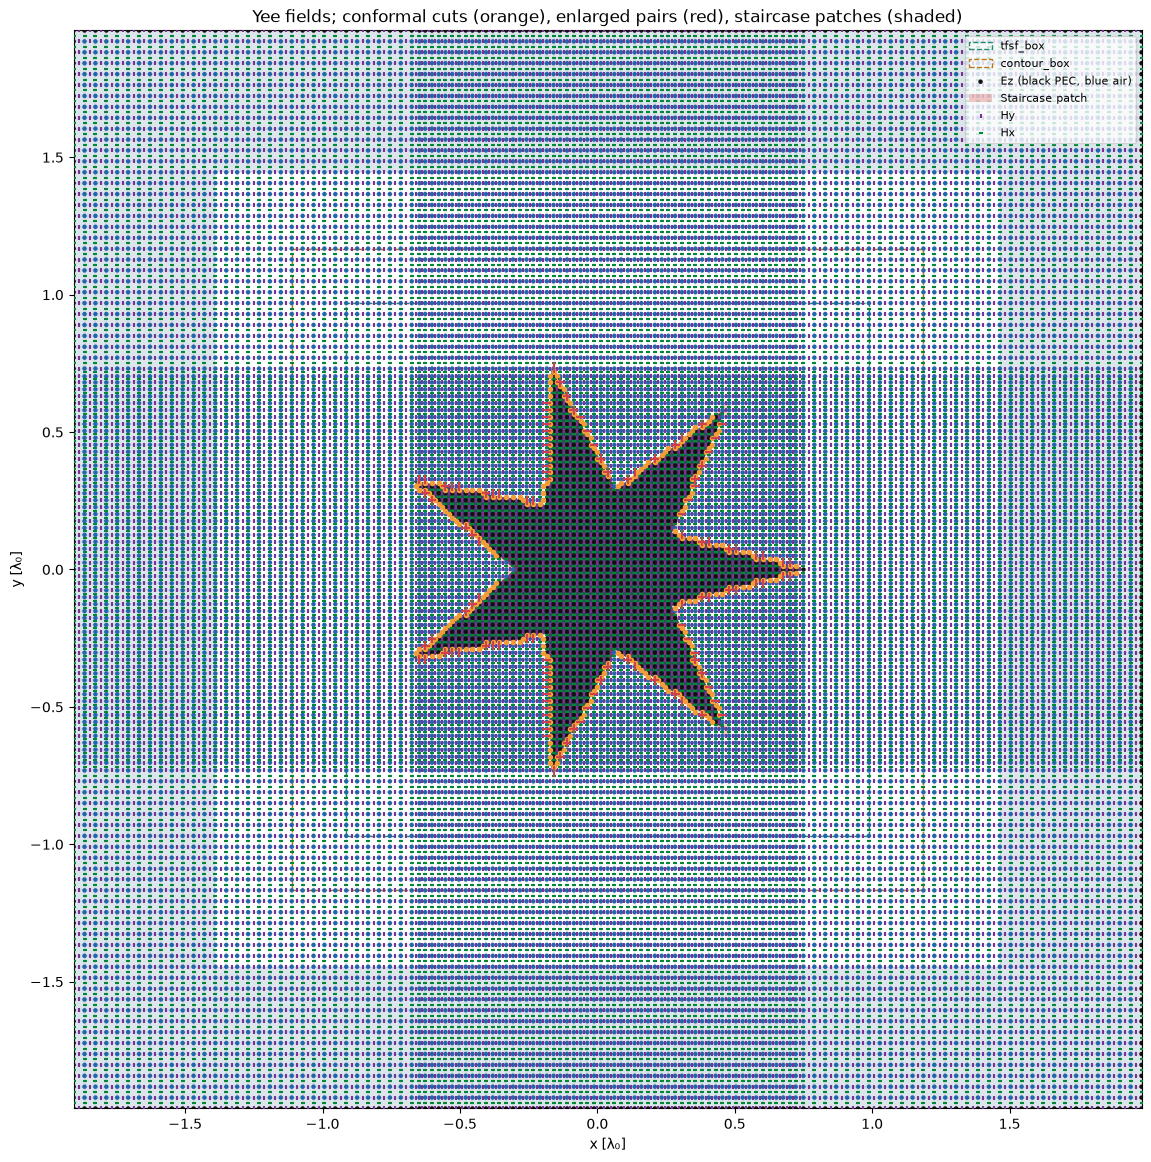

star 0 (120, 120) {'fallback_cells': 22, 'fallback_area_m2': 0.001225485369885683, 'fallback_max_diameter_m': 0.03745594696744489, 'patches': [{'cells': 8, 'area_m2': 0.0004456310435947944, 'bounds': [0.46459381397077115, 0.4867018534768465, 0.5728816098619406, 0.6031170617756437], 'diameter_m': 0.03745594696744489}, {'cells': 2, 'area_m2': 0.00011140776089869881, 'bounds': [0.5825033580031732, 0.5898727045051984, 0.48973411709925696, 0.5048518430561085], 'diameter_m': 0.01681823135687501}, {'cells': 2, 'area_m2': 0.00011140776089869881, 'bounds': [0.5825033580031732, 0.5898727045051984, 0.6711468285814758, 0.6862645545383274], 'diameter_m': 0.01681823135687501}, {'cells': 2, 'area_m2': 0.00011140776089869881, 'bounds': [0.6488274765213995, 0.6635661695254498, 0.5350872949698117, 0.5426461579482375], 'diameter_m': 0.016563981435459795}, {'cells': 2, 'area_m2': 0.00011140776089869553, 'bounds': [0.6488274765213995, 0.6635661695254498, 0.633352513689347, 0.6409113766677725], 'diameter_m'

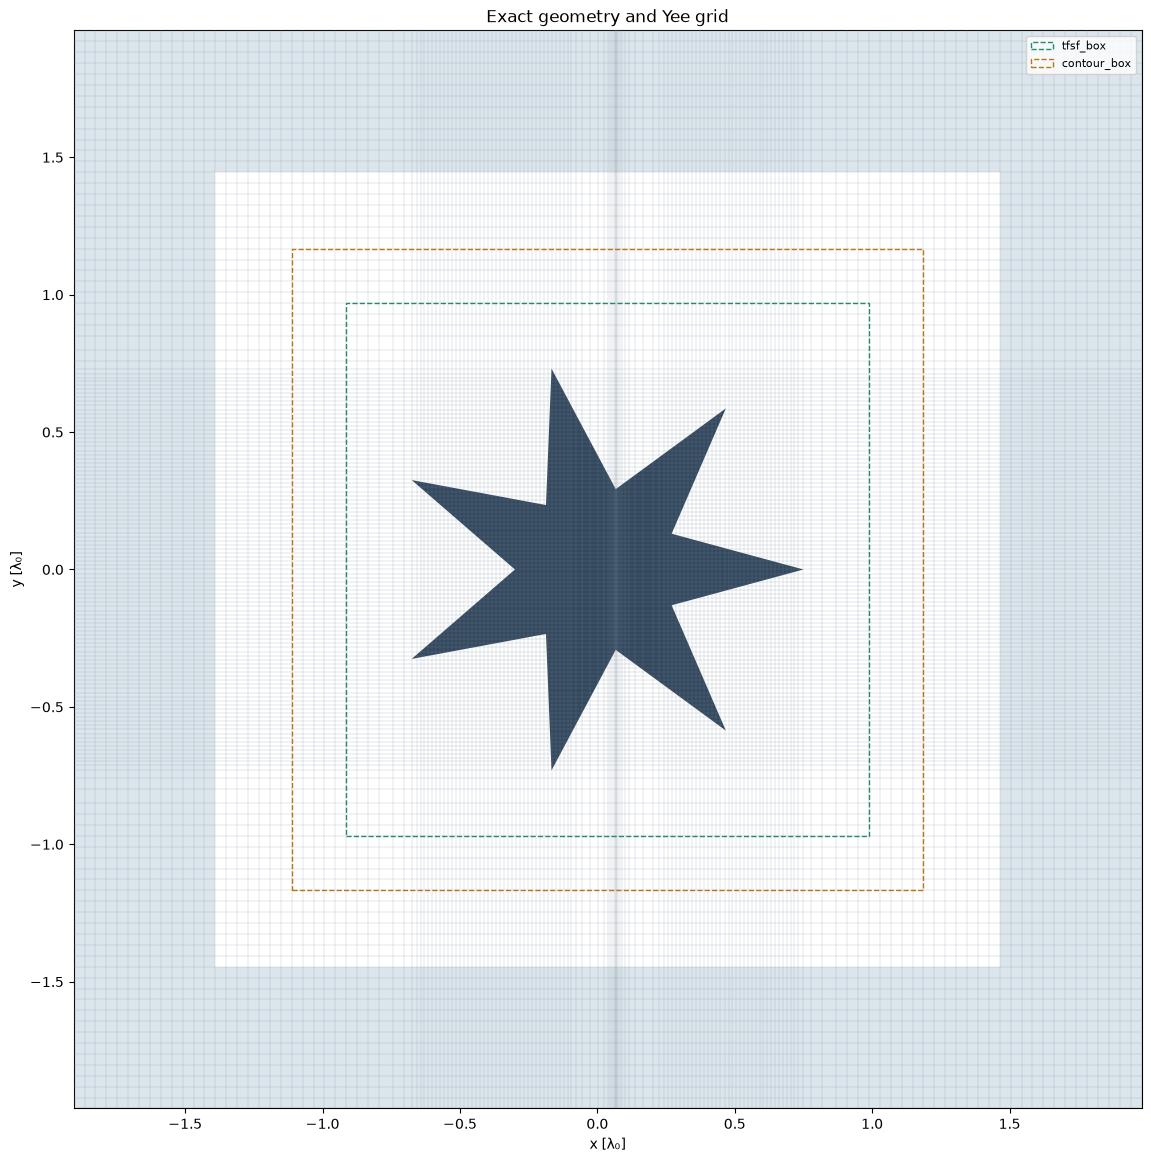

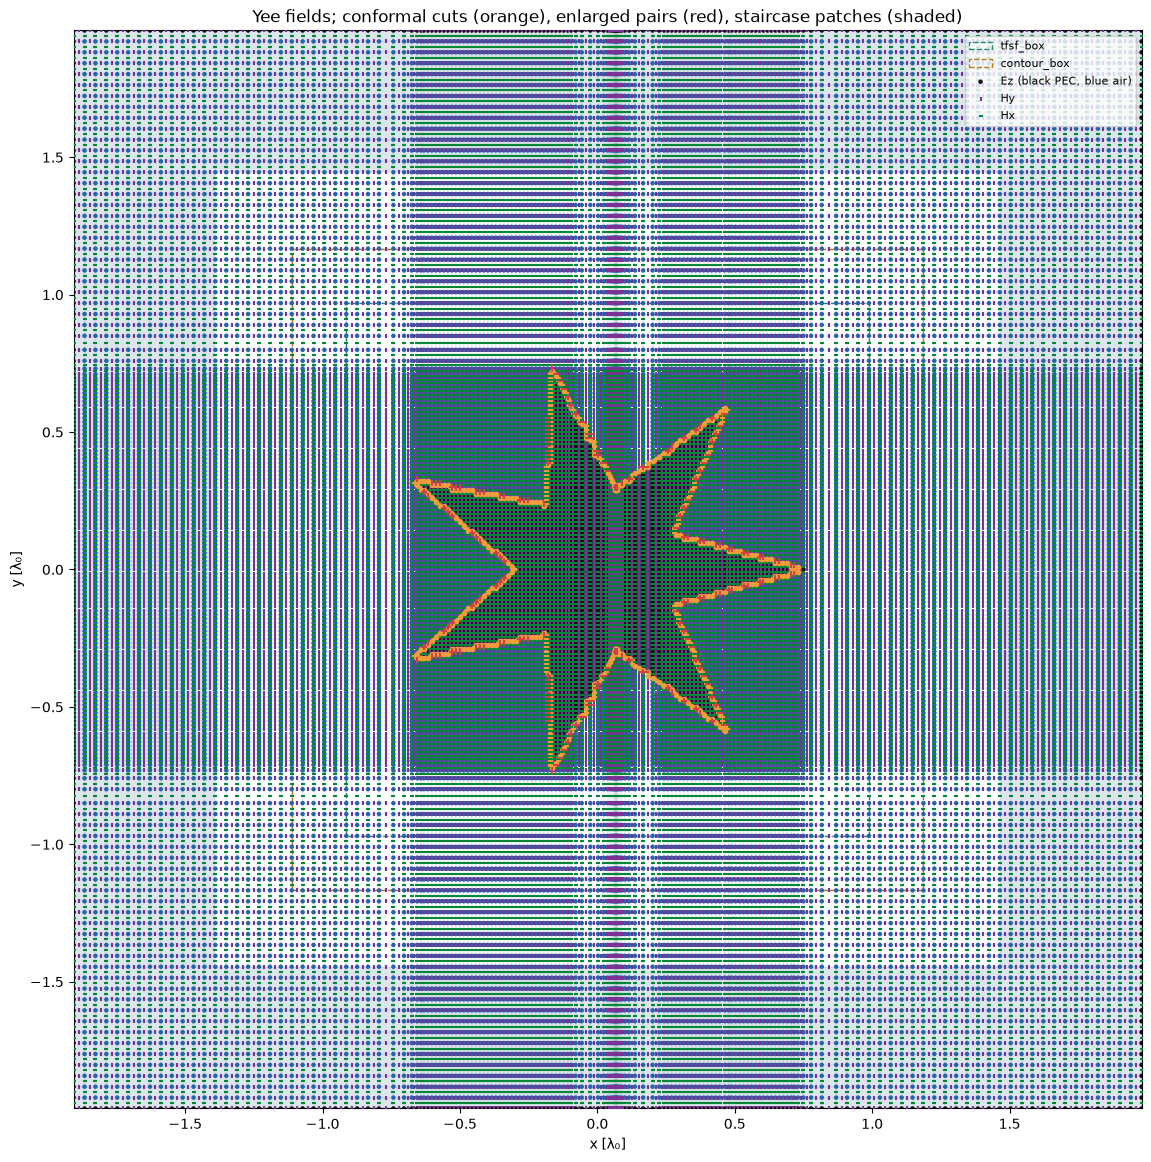

star 0 (160, 160) {'fallback_cells': 0, 'fallback_area_m2': 0.0, 'fallback_max_diameter_m': 0.0, 'patches': [], 'termination_reason': 'fully_conformal', 'passes': [{'cells': [160, 160], 'anchors': [1, 1], 'assignment': 'local', 'status': 'valid', 'violations': 4, 'topology_violations': 2, 'donor_violations': 2, 'fallback_cells': 8, 'fallback_area_m2': 0.00015609150673187453, 'fallback_max_diameter_m': 0.009953647129579172}, {'cells': [160, 160], 'anchors': [5, 1], 'assignment': 'local', 'status': 'projection_infeasible', 'message': 'No mesh satisfies anchors, fixed collars, budget and grading/spacing'}, {'cells': [160, 160], 'anchors': [5, 1], 'assignment': 'joint', 'status': 'valid', 'violations': 0, 'topology_violations': 0, 'donor_violations': 0, 'fallback_cells': 0, 'fallback_area_m2': 0.0, 'fallback_max_diameter_m': 0.0}]}


C:\Users\Traveler\PycharmProjects\FDTD_ML\src\fdtdmesh\solver\coefficients.py:36: StaircaseFallbackWarning: Local staircase fallback in 46 cells (0.188% domain area); thin PEC/gaps may be lost. Inspect discretization diagnostics.
  pec, hx, hy, bound = build_conformal(scene, mesh, boundary=boundary, report=report, warn=True)


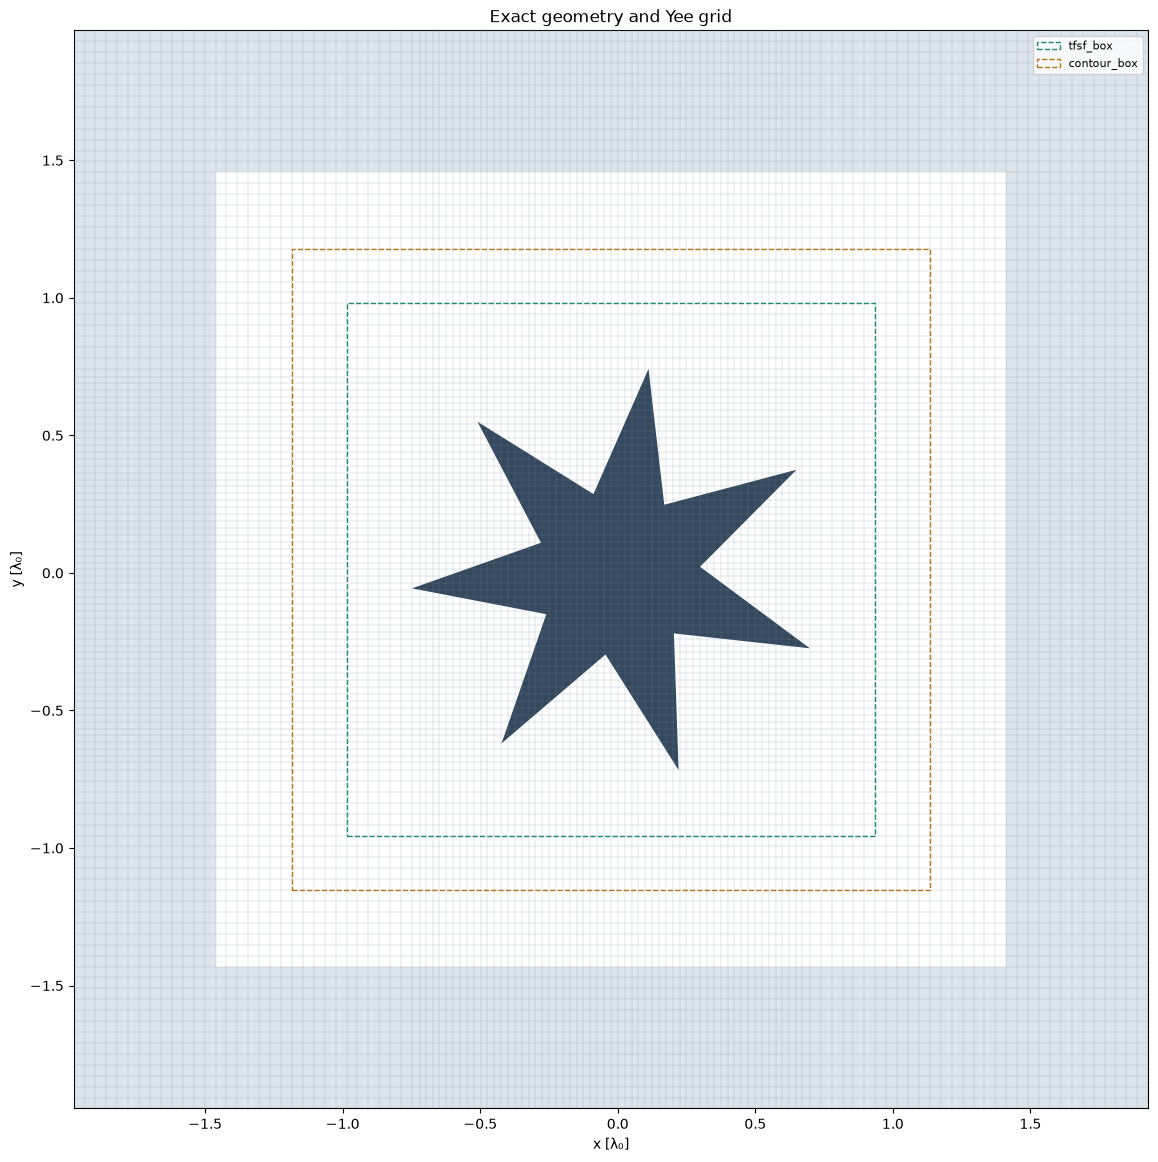

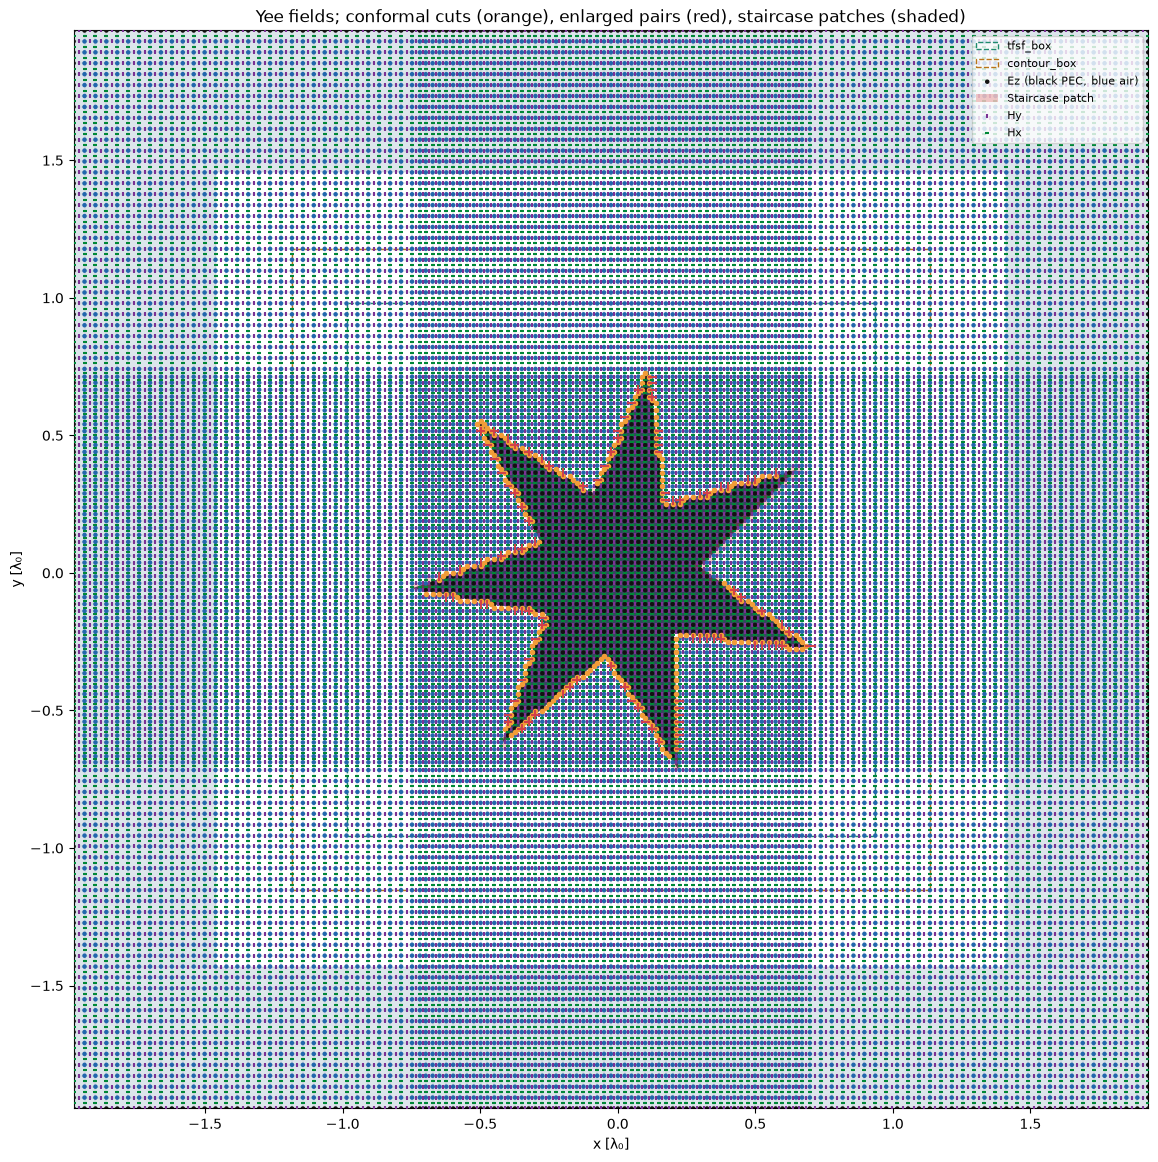

star 30 (120, 120) {'fallback_cells': 46, 'fallback_area_m2': 0.002583940362569537, 'fallback_max_diameter_m': 0.1745810858853294, 'patches': [{'cells': 4, 'area_m2': 0.0002253610499731816, 'bounds': [0.3687923094444444, 0.39121561961728235, 0.5647732079203638, 0.5798486616492807], 'diameter_m': 0.027019884238094233}, {'cells': 2, 'area_m2': 0.0001126805249865881, 'bounds': [0.4659599868600754, 0.4734344235843546, 0.3914054900378198, 0.40648094376673666], 'diameter_m': 0.016826660675189425}, {'cells': 2, 'area_m2': 0.00011268052498659059, 'bounds': [0.49585773375719266, 0.5108066072057512, 0.6250750228360313, 0.6326127497004899], 'diameter_m': 0.016741748524697134}, {'cells': 2, 'area_m2': 0.00011268052498658976, 'bounds': [0.5631276642757064, 0.5706021009999857, 0.6627636571583235, 0.6778391108872405], 'diameter_m': 0.01682666067518955}, {'cells': 2, 'area_m2': 0.00011268052498658934, 'bounds': [0.652820904967058, 0.6602953416913373, 0.36879230944444447, 0.38386776317336135], 'diamete

C:\Users\Traveler\PycharmProjects\FDTD_ML\src\fdtdmesh\solver\coefficients.py:36: StaircaseFallbackWarning: Local staircase fallback in 24 cells (0.035% domain area); thin PEC/gaps may be lost. Inspect discretization diagnostics.
  pec, hx, hy, bound = build_conformal(scene, mesh, boundary=boundary, report=report, warn=True)


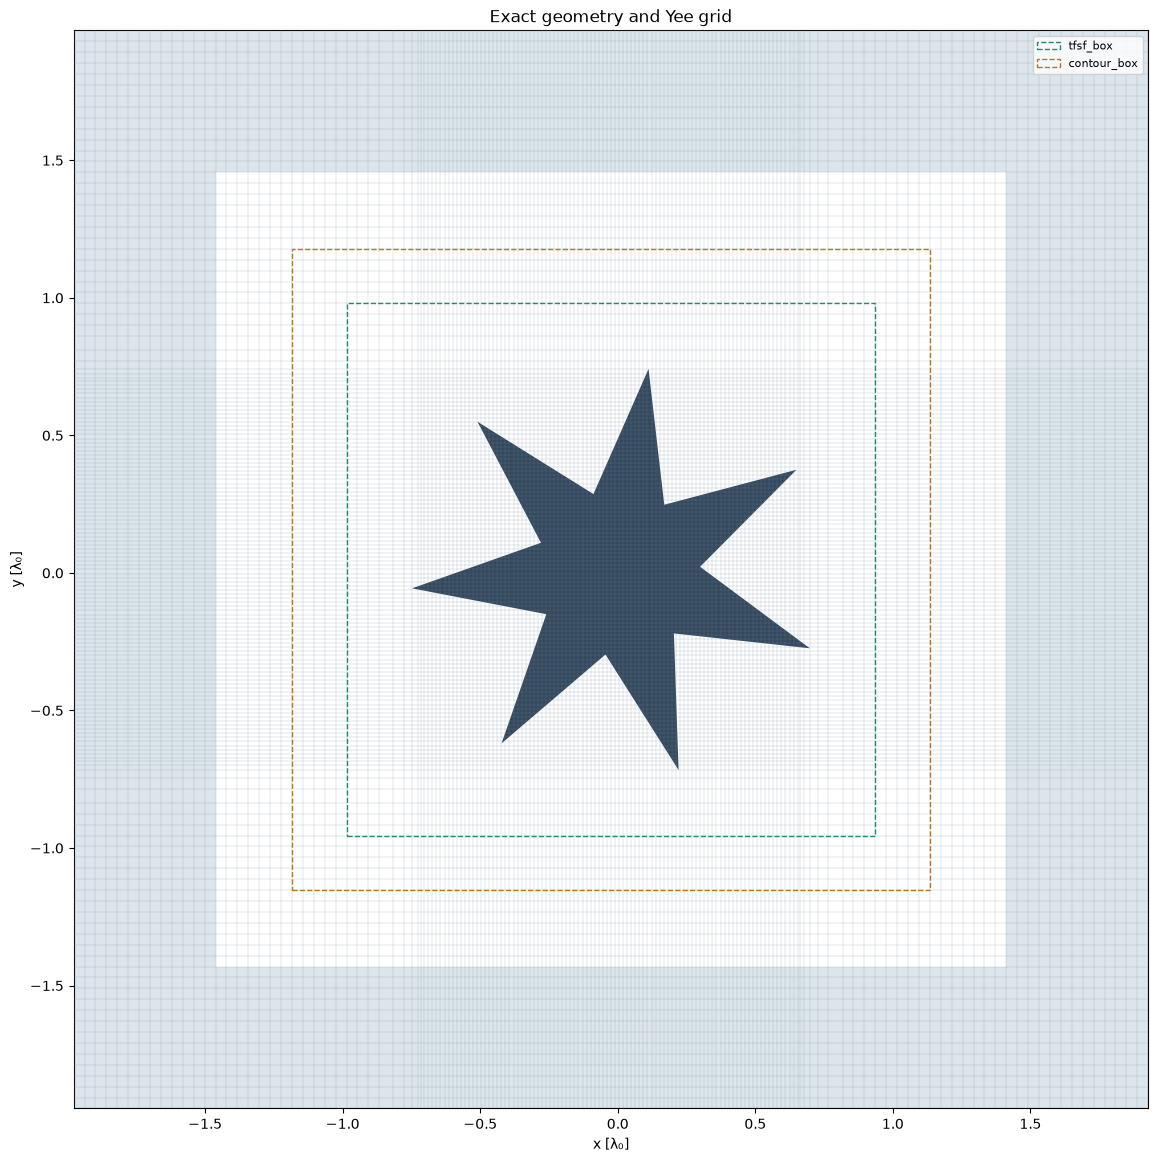

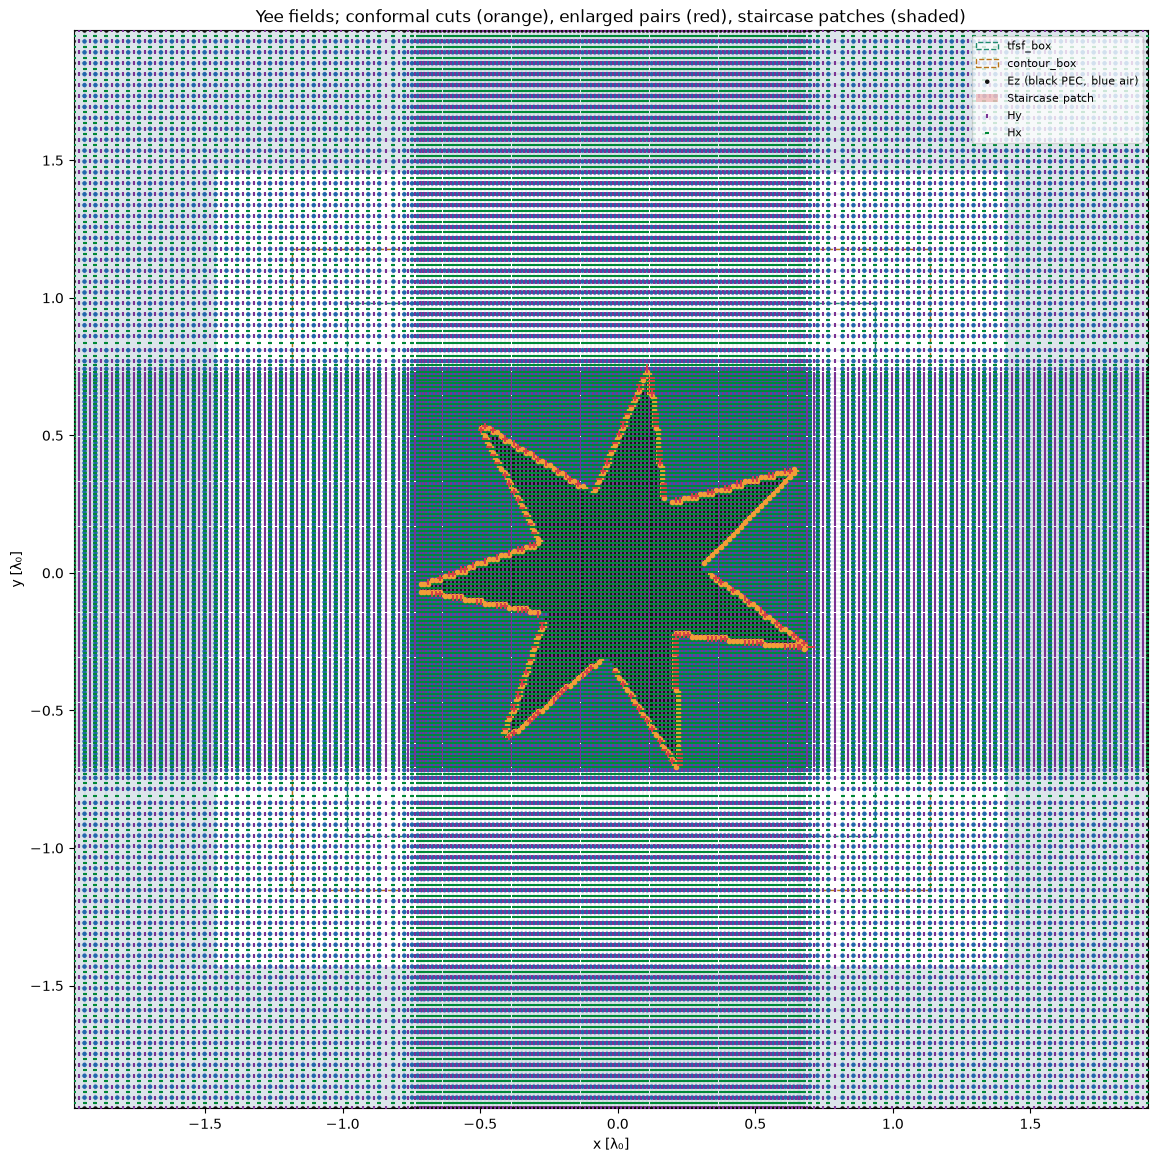

star 30 (160, 160) {'fallback_cells': 24, 'fallback_area_m2': 0.0004802023789047409, 'fallback_max_diameter_m': 0.022238276604476984, 'patches': [{'cells': 2, 'area_m2': 4.604680345662023e-05, 'bounds': [0.3687923094444444, 0.3791141506351159, 0.5650808702413621, 0.5695419738958376], 'diameter_m': 0.011244636560663799}, {'cells': 2, 'area_m2': 3.9468688677102415e-05, 'bounds': [0.4395706490376199, 0.44399429526219336, 0.7435250164203782, 0.752447223729329], 'diameter_m': 0.009958635909806106}, {'cells': 2, 'area_m2': 3.9468688677101676e-05, 'bounds': [0.46611252638506073, 0.47053617260963415, 0.3955589313712969, 0.4044811386802477], 'diameter_m': 0.009958635909806031}, {'cells': 4, 'area_m2': 7.893737735420286e-05, 'bounds': [0.5103489886307954, 0.5191962810799422, 0.5338531446600343, 0.5427753519689851], 'diameter_m': 0.012565045441407094}, {'cells': 2, 'area_m2': 3.9468688677102415e-05, 'bounds': [0.5590090971011035, 0.5634327433256769, 0.6676862542942964, 0.6766084616032473], 'diame

In [3]:
prepared = {}
for name in CASES:
    for angle in ORIENTATIONS:
        key = (name, angle)
        prepared[key] = {}
        for budget in BUDGETS:
            try:
                sim = make_sim(name, angle)
                sim.apply_mesh('geometry_aware', cells=budget, options=MeshOptions(hybrid_repair_passes=3))
            except (ValueError, RuntimeError) as exc:
                print('skipping rejected preparation', name, angle, budget, type(exc).__name__, exc)
                continue
            prepared[key][budget] = sim
            case_dir = OUT / f'{name}_{angle:g}'
            case_dir.mkdir(parents=True, exist_ok=True)
            fig = sim.plot_geometry(mesh=True, units='wavelength', figsize=(16, 14))
            fig.savefig(case_dir / f'geometry_{budget[0]}x{budget[1]}.png', dpi=120, bbox_inches='tight')
            plt.show(); plt.close(fig)
            fig = sim.plot_discretization(units='wavelength', show_fallback=True, figsize=(16, 14))
            fig.savefig(case_dir / f'fallback_{budget[0]}x{budget[1]}.png', dpi=120, bbox_inches='tight')
            plt.show(); plt.close(fig)
            report = sim.discretization.boundary_report
            ga = sim.mesh.metadata.get('geometry_aware', {})
            print(name, angle, budget, {
                'fallback_cells': report.get('fallback_cells'),
                'fallback_area_m2': report.get('fallback_area_m2'),
                'fallback_max_diameter_m': report.get('fallback_max_diameter_m'),
                'patches': report.get('patches', []),
                'termination_reason': ga.get('termination_reason'),
                'passes': ga.get('passes'),
            })


## Qualified hybrid references and bounded optimization

Qualification starts from an independently prepared 120×120 seed for each shape/orientation. The requested subdivided factors and hybrid boundary mode are part of the reference settings. Archives contain reference reports, search histories, and best meshes under `ROOT/artifacts/notebooks/hybrid_tip_optimization/case_angle/...`.

In [4]:
reference_settings = ReferenceSettings(
    boundary_mode='hybrid', method='subdivide', factors=(2, 3, 4, 6, 8),
)
search_settings = SearchSettings(
    max_evaluations=MAX_EVALUATIONS, max_seconds=600, projection_seconds=5,
)
def progress(row):
    print({key: row[key] for key in ('number', 'resolution', 'status', 'best_error', 'difference') if key in row}, flush=True)

references = {}
optimizations = {}

if RUN_GPU:
    for name in CASES:
        for angle in ORIENTATIONS:
            key = (name, angle)
            case_dir = OUT / f'{name}_{angle:g}'
            seed_sim = make_sim(name, angle)
            try:
                seed_sim.apply_mesh('geometry_aware', cells=(120, 120), options=MeshOptions(hybrid_repair_passes=3))
                reference = qualify_reference(seed_sim, directory=case_dir / 'reference', settings=reference_settings, initial_mesh=seed_sim.mesh, progress=progress)
            except (ValueError, RuntimeError) as exc:
                print('reference failed', key, type(exc).__name__, str(exc))
                continue
            references[key] = reference
            print('reference', key, 'qualified=', reference.qualified, 'status=', reference.report.get('status'))
            if not reference.qualified:
                continue
            for budget in BUDGETS:
                sim = make_sim(name, angle)
                archive = case_dir / f'budget_{budget[0]}x{budget[1]}'
                try:
                    result = optimize_mesh(
                        sim, reference, cells=budget, directory=archive,
                        strategy='feasible_local', settings=search_settings,
                        progress=progress,  # optimize_mesh defaults to hybrid
                    )
                except (ValueError, RuntimeError) as exc:
                    print('optimization failed', key, budget, type(exc).__name__, str(exc))
                    continue
                optimizations[key, budget] = result
                print('optimization', key, budget, 'status=', result.report.get('status'))


## Optimization plots and convergence reading

When GPU work is enabled, inspect the saved best mesh plot, history plot, and reference-vs-best polar complex-magnitude plot for every budget. Fixed-exterior optimization budgets are search comparisons, not a reference convergence protocol; use the full-domain subdivision checks in the qualified reference for spatial qualification, alongside the tighter stopping check for temporal qualification. A zero fallback count is not a convergence certificate.

In [5]:
summary_rows = []
if RUN_GPU:
    for (key, budget), optimization in optimizations.items():
        best = optimization.best
        if best is None:
            continue
        name, angle = key
        case_dir = OUT / f'{name}_{angle:g}' / f'budget_{budget[0]}x{budget[1]}'
        case_dir.mkdir(parents=True, exist_ok=True)
        best_sim = make_sim(name, angle)
        best_sim.apply_mesh('custom', mesh=best.mesh)
        fig = best_sim.plot_geometry(mesh=True, units='wavelength', figsize=(16, 14))
        fig.savefig(case_dir / 'best_mesh.png', dpi=120, bbox_inches='tight')
        plt.show(); plt.close(fig)
        fig = optimization.plot_history()
        fig.savefig(case_dir / 'history.png', dpi=120, bbox_inches='tight')
        plt.show(); plt.close(fig)
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 7))
        references[key].result.plot_far_field(component='magnitude', ax=ax)
        best.plot_far_field(component='magnitude', ax=ax)
        ax.legend(['qualified reference', 'best mesh'])
        fig.savefig(case_dir / 'reference_vs_best_polar.png', dpi=120, bbox_inches='tight')
        plt.show(); plt.close(fig)
        trials = [t.get('error') for t in optimization.report.get('trials', []) if t.get('error') is not None]
        baseline_error = trials[0] if trials else None
        best_error = optimization.report.get('best_error')
        report = best_sim.discretization.boundary_report
        summary_rows.append({'case': name, 'angle_deg': angle, 'budget': budget, 'baseline_error': baseline_error, 'best_error': best_error, 'fallback_area_m2': report.get('fallback_area_m2'), 'fallback_max_diameter_m': report.get('fallback_max_diameter_m')})
        (case_dir / 'history_summary.json').write_text(json.dumps({'budget': budget, 'trials': optimization.report.get('trials', [])}, indent=2), encoding='utf-8')
from IPython.display import Markdown, display
if summary_rows:
    table = ['| Case | Angle | Budget | Seed error | Best error | Patch area (mm²) | Max diameter (mm) |',
             '|---|---:|---|---:|---:|---:|---:|']
    for row in summary_rows:
        table.append(f"| {row['case']} | {row['angle_deg']} | {row['budget']} | {row['baseline_error']:.3%} | {row['best_error']:.3%} | {row['fallback_area_m2']*1e6:.3f} | {row['fallback_max_diameter_m']*1e3:.3f} |")
    display(Markdown('\n'.join(table)))
